In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from io import BytesIO
from docx import Document
from docx.shared import Pt, Inches

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [2]:
df = pd.read_csv("labeled_cv_data.csv", encoding="utf-8-sig")
df = df.dropna()

df.head()

,text,label
0,দক্ষ ও স্কেলেবল সফটওয়্যার সলিউশন ডেভেলপমেন্টে...,Objective
1,জুনিয়র সফটওয়্যার ইঞ্জিনিয়ার |,Experience
2,টেক গার্ডেন সফটওয়্যার |,Experience
3,নভেম্বর ২০২০ - বর্তমান,Experience
4,পাইথন এবং জ্যাঙ্গো ফ্রেমওয়ার্ক ব্যবহার করে ব্...,Experience


In [3]:
target_labels = ['Experience', 'Skill', 'Education', 'Objective']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

In [5]:
tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [6]:
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_tfidf, y_train)

svm_model = SVC(kernel='linear', probability=True, class_weight='balanced')
svm_model.fit(X_train_tfidf, y_train)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_tfidf, y_train)

print("All models trained!")

All models trained!


In [7]:
models = {
    "Logistic Regression": lr_model,
    "SVM": svm_model,
    "KNN": knn_model
}

train_accuracies = []
test_accuracies = []

for name, model in models.items():
    train_accuracies.append(model.score(X_train_tfidf, y_train))
    test_accuracies.append(model.score(X_test_tfidf, y_test))

train_loss = [1 - acc for acc in train_accuracies]
test_loss = [1 - acc for acc in test_accuracies]

x = np.arange(len(models))

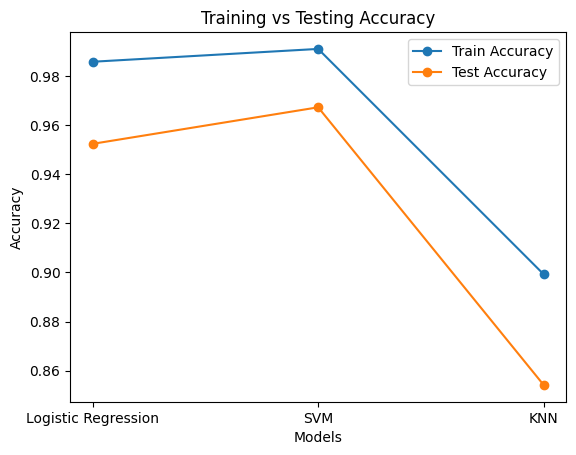

In [8]:
plt.figure()

plt.plot(x, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(x, test_accuracies, marker='o', label='Test Accuracy')

plt.xticks(x, list(models.keys()))
plt.title("Training vs Testing Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

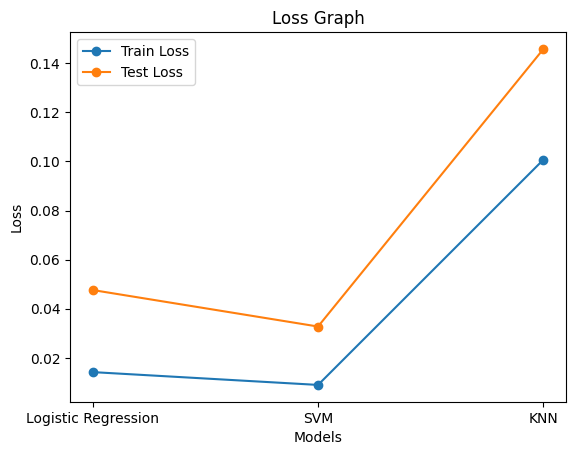

In [9]:
plt.figure()

plt.plot(x, train_loss, marker='o', label='Train Loss')
plt.plot(x, test_loss, marker='o', label='Test Loss')

plt.xticks(x, list(models.keys()))
plt.title("Loss Graph")
plt.xlabel("Models")
plt.ylabel("Loss")
plt.legend()

plt.show()

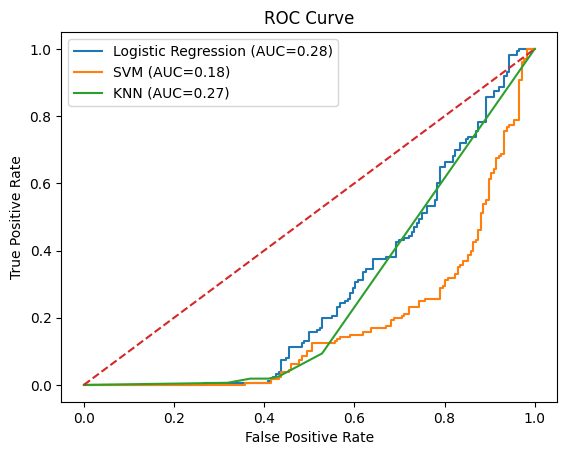

In [10]:
y_test_bin = label_binarize(y_test, classes=target_labels)
n_classes = y_test_bin.shape[1]

plt.figure()

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_tfidf)
        
        fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_score[:, 0])
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [11]:
joblib.dump(lr_model, 'cv_model_logistic.pkl')
joblib.dump(svm_model, 'cv_model_svm.pkl')
joblib.dump(knn_model, 'cv_model_knn.pkl')
joblib.dump(tfidf, 'cv_tfidf_vectorizer.pkl')

['cv_tfidf_vectorizer.pkl']

In [12]:
doc = Document()
doc.add_heading('Bangla CV Model Performance Report', 0)

In [13]:
def add_report(name, model):
    doc.add_heading(f'Model: {name}', level=1)

    predictions = model.predict(X_test_tfidf)

    report = classification_report(
        y_test,
        predictions,
        labels=target_labels,
        zero_division=0
    )

    doc.add_paragraph(report)

    # Confusion Matrix
    cm = confusion_matrix(y_test, predictions, labels=target_labels)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=target_labels,
                yticklabels=target_labels)

    mem = BytesIO()
    plt.savefig(mem, format='png')
    mem.seek(0)
    plt.close()

    doc.add_picture(mem, width=Inches(5))

In [14]:
add_report("Logistic Regression", lr_model)
add_report("SVM", svm_model)
add_report("KNN", knn_model)

In [15]:
# Accuracy Graph
plt.figure()
plt.plot(x, train_accuracies, marker='o')
plt.plot(x, test_accuracies, marker='o')
plt.xticks(x, list(models.keys()))

mem = BytesIO()
plt.savefig(mem, format='png')
mem.seek(0)
plt.close()

doc.add_heading("Accuracy Graph", level=1)
doc.add_picture(mem, width=Inches(5))

# Loss Graph
plt.figure()
plt.plot(x, train_loss, marker='o')
plt.plot(x, test_loss, marker='o')
plt.xticks(x, list(models.keys()))

mem = BytesIO()
plt.savefig(mem, format='png')
mem.seek(0)
plt.close()

doc.add_heading("Loss Graph", level=1)
doc.add_picture(mem, width=Inches(5))

# ROC
plt.figure()

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_tfidf)
        fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_score[:, 0])
        plt.plot(fpr, tpr)

mem = BytesIO()
plt.savefig(mem, format='png')
mem.seek(0)
plt.close()

doc.add_heading("ROC Curve", level=1)
doc.add_picture(mem, width=Inches(5))

In [16]:
doc.save("Model_Performance_Visual_Report.docx")

print("Report created successfully!")

Report created successfully!
